# Emotion Classification Fine-tuning
Notebook Kaggle dùng `bhadresh-savani/bert-base-uncased-emotion` trên `dair-ai/emotion`.


In [1]:
!pip -q install transformers datasets accelerate scikit-learn matplotlib seaborn


In [2]:
import os, math, random, warnings, logging
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding, EarlyStoppingCallback
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.preprocessing import label_binarize
from scipy.interpolate import make_interp_spline
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("datasets").setLevel(logging.ERROR)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

MODEL_NAME   = "bhadresh-savani/bert-base-uncased-emotion"
DATASET_NAME = "dair-ai/emotion"
LABEL_NAMES  = ["sadness", "joy", "love", "anger", "fear", "surprise"]
NUM_LABELS   = 6
MAX_LENGTH   = 128
OUTPUT_DIR   = "/kaggle/working/emotion_finetune"
os.makedirs(OUTPUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [3]:
print('Loading dataset...')
ds = load_dataset(DATASET_NAME)
print(ds)
print('Train size:', len(ds['train']))
print('Validation size:', len(ds['validation']))
print('Test size:', len(ds['test']))


Loading dataset...


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
Train size: 16000
Validation size: 2000
Test size: 2000


## Dataset Overview


,Label,Train,Validation,Test,Train %,Validation %,Test %
0,sadness,4666,550,581,29.2,27.5,29.0
1,joy,5362,704,695,33.5,35.2,34.8
2,love,1304,178,159,8.2,8.9,8.0
3,anger,2159,275,275,13.5,13.8,13.8
4,fear,1937,212,224,12.1,10.6,11.2
5,surprise,572,81,66,3.6,4.0,3.3


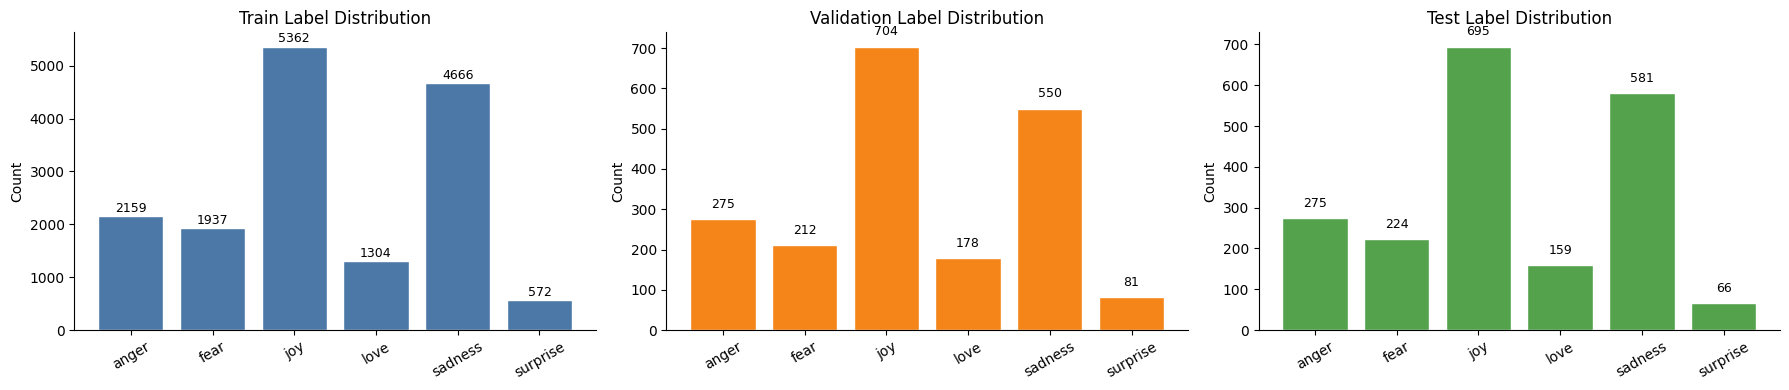

In [4]:
label_map = {i: name for i, name in enumerate(LABEL_NAMES)}

train_counts = pd.Series(ds["train"]["label"]).map(label_map).value_counts().sort_index()
val_counts   = pd.Series(ds["validation"]["label"]).map(label_map).value_counts().sort_index()
test_counts  = pd.Series(ds["test"]["label"]).map(label_map).value_counts().sort_index()

# Bảng thống kê
stats_df = pd.DataFrame({
    "Label":      LABEL_NAMES,
    "Train":      [train_counts.get(n, 0) for n in LABEL_NAMES],
    "Validation": [val_counts.get(n, 0)   for n in LABEL_NAMES],
    "Test":       [test_counts.get(n, 0)  for n in LABEL_NAMES],
})
stats_df["Train %"]      = (stats_df["Train"]      / stats_df["Train"].sum()      * 100).round(1)
stats_df["Validation %"] = (stats_df["Validation"] / stats_df["Validation"].sum() * 100).round(1)
stats_df["Test %"]       = (stats_df["Test"]       / stats_df["Test"].sum()       * 100).round(1)
display(stats_df)

# Biểu đồ phân phối nhãn
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=False)
palette = ["#4C78A8", "#F58518", "#54A24B"]
for ax, (counts, title, color) in zip(axes, [
    (train_counts, "Train Label Distribution", palette[0]),
    (val_counts,   "Validation Label Distribution", palette[1]),
    (test_counts,  "Test Label Distribution",  palette[2]),
]):
    bars = ax.bar(counts.index, counts.values, color=color, edgecolor="white")
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 20, str(v),
                ha="center", va="bottom", fontsize=9)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("/kaggle/working/label_distribution.png", dpi=150)
plt.show()


In [5]:
print('Loading tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)

train_ds = ds['train'].rename_column('label', 'labels').map(tokenize_fn, batched=True)
val_ds   = ds['validation'].rename_column('label', 'labels').map(tokenize_fn, batched=True)
test_ds  = ds['test'].rename_column('label', 'labels').map(tokenize_fn, batched=True)

train_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
val_ds.set_format('torch',   columns=['input_ids', 'attention_mask', 'labels'])
test_ds.set_format('torch',  columns=['input_ids', 'attention_mask', 'labels'])
print('Tokenization done.')


Loading tokenizer...


config.json:   0%|          | 0.00/935 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenization done.


## Model (Full Fine-tuning)


Loading model...


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,Label,Count,Weight
0,sadness,4666,0.5715
1,joy,5362,0.4973
2,love,1304,2.0450
3,anger,2159,1.2351
4,fear,1937,1.3767
5,surprise,572,4.6620


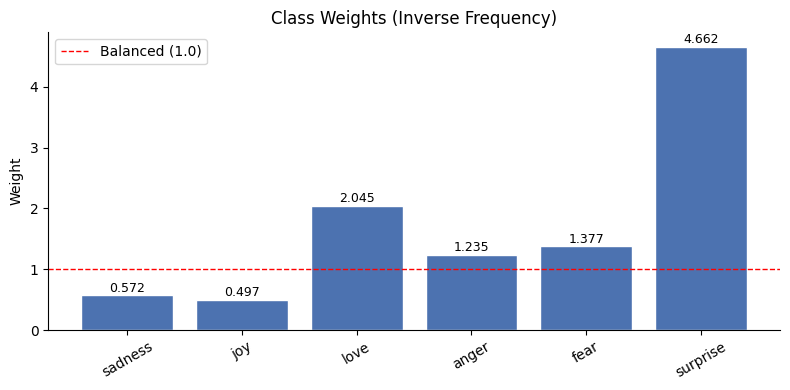

Total parameters   : 109,486,854
Trainable params   : 109,486,854


In [6]:
print('Loading model...')
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label={i: n for i, n in enumerate(LABEL_NAMES)},
    label2id={n: i for i, n in enumerate(LABEL_NAMES)}
)

counts  = np.bincount(ds['train']['label'], minlength=NUM_LABELS)
weights = counts.sum() / (NUM_LABELS * np.clip(counts, 1, None))
class_weights = torch.tensor(weights, dtype=torch.float)

# Bảng class weights
cw_df = pd.DataFrame({"Label": LABEL_NAMES, "Count": counts, "Weight": weights.round(4)})
display(cw_df)

# Biểu đồ class weights
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(LABEL_NAMES, weights, color="#4C72B0", edgecolor="white")
for bar, v in zip(bars, weights):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.3f}",
            ha="center", va="bottom", fontsize=9)
ax.axhline(1.0, color="red", linestyle="--", linewidth=1, label="Balanced (1.0)")
ax.set_title("Class Weights (Inverse Frequency)")
ax.set_ylabel("Weight")
ax.tick_params(axis="x", rotation=30)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/class_weights.png", dpi=150)
plt.show()

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters   : {total_params:,}")
print(f"Trainable params   : {trainable_params:,}")


In [7]:
class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device),
            label_smoothing=0.05
        )
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


## Compute Metrics


In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(torch.tensor(logits, dtype=torch.float32), dim=-1).numpy()

    lb = label_binarize(labels, classes=list(range(NUM_LABELS)))
    roc_auc_values = []
    for c in range(NUM_LABELS):
        try:
            roc_auc_values.append(roc_auc_score(lb[:, c], probs[:, c]))
        except Exception:
            roc_auc_values.append(float("nan"))

    # Lưu nội bộ để dùng lại ở cell visualization sau
    global _last_probs, _last_roc_auc_per_class
    _last_probs = probs
    _last_roc_auc_per_class = {LABEL_NAMES[c]: roc_auc_values[c] for c in range(NUM_LABELS)}

    return {
        "accuracy":        float(accuracy_score(labels, preds)),
        "precision_macro": float(precision_score(labels, preds, average="macro", zero_division=0)),
        "recall_macro":    float(recall_score(labels, preds, average="macro", zero_division=0)),
        "f1_macro":        float(f1_score(labels, preds, average="macro", zero_division=0)),
        "f1_weighted":     float(f1_score(labels, preds, average="weighted", zero_division=0)),
        "roc_auc_macro":   float(np.nanmean(roc_auc_values)),
    }

In [9]:
steps_per_epoch = math.ceil(len(train_ds) / 16)
training_args = TrainingArguments(
    disable_tqdm=False,
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    learning_rate=5e-6,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    warmup_steps=max(50, int(0.06 * steps_per_epoch * 4)),
    lr_scheduler_type='cosine',
    eval_strategy='steps',
    eval_steps=50,
    save_strategy='steps',
    save_steps=50,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_macro",
    greater_is_better=True,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    report_to='none',
    seed=SEED,
)

trainer = WeightedTrainer(
    class_weights=class_weights,
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=10)],
)

print('Training...')
trainer.train()
log_history = pd.DataFrame(trainer.state.log_history)

train_log = log_history[log_history["loss"].notna()][[
    "step", "epoch", "loss", "learning_rate"
]].reset_index(drop=True)

eval_cols_base = ["step", "epoch", "eval_loss", "eval_accuracy",
                  "eval_precision_macro", "eval_recall_macro",
                  "eval_f1_macro", "eval_f1_weighted", "eval_roc_auc_macro"]
eval_cols_auc  = [f"eval_roc_auc_{n}" for n in LABEL_NAMES]
eval_cols_all  = [c for c in eval_cols_base + eval_cols_auc if c in log_history.columns]
eval_log = log_history[log_history["eval_loss"].notna()][eval_cols_all].reset_index(drop=True)

train_log.to_csv("/kaggle/working/train_log.csv", index=False)
eval_log.to_csv("/kaggle/working/eval_log.csv", index=False)
print("=== Train log ===")
print(train_log)
print("\n=== Eval log ===")
print(eval_log)


Training...


Step,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted,Roc Auc Macro
50,0.664703,0.759974,0.936500,0.904737,0.929594,0.916159,0.937165,0.997352
100,0.609375,0.643162,0.925500,0.874483,0.933337,0.898165,0.927608,0.996491
150,0.524255,0.551954,0.929000,0.881091,0.931776,0.900875,0.930736,0.995989
200,0.456697,0.518015,0.935000,0.895231,0.933729,0.912430,0.935894,0.996361
250,0.476769,0.500045,0.935500,0.890351,0.941213,0.911954,0.936840,0.996862
300,0.448481,0.508145,0.939500,0.905078,0.927837,0.915639,0.940105,0.996850
350,0.448012,0.511269,0.943000,0.915640,0.929784,0.922323,0.943226,0.996564
400,0.448554,0.519905,0.936500,0.903610,0.921316,0.911799,0.937057,0.996639
450,0.448183,0.503729,0.941500,0.909137,0.935921,0.921332,0.942078,0.996840
500,0.438277,0.499858,0.938500,0.900210,0.941865,0.918516,0.939457,0.996629


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

=== Train log ===
    step  epoch      loss  learning_rate
0     50    0.1  0.664703       0.000001
1    100    0.2  0.609375       0.000002
2    150    0.3  0.524255       0.000003
3    200    0.4  0.456697       0.000004
4    250    0.5  0.476769       0.000005
5    300    0.6  0.448481       0.000005
6    350    0.7  0.448012       0.000005
7    400    0.8  0.448554       0.000005
8    450    0.9  0.448183       0.000005
9    500    1.0  0.438277       0.000004
10   550    1.1  0.416811       0.000004
11   600    1.2  0.439227       0.000004
12   650    1.3  0.427442       0.000004
13   700    1.4  0.438301       0.000004
14   750    1.5  0.428057       0.000003
15   800    1.6  0.440393       0.000003
16   850    1.7  0.423219       0.000003

=== Eval log ===
    step  epoch  eval_loss  eval_accuracy  eval_precision_macro  \
0     50    0.1   0.759974         0.9365              0.904737   
1    100    0.2   0.643162         0.9255              0.874483   
2    150    0.3   0.55195

In [10]:
print('Best checkpoint:', trainer.state.best_model_checkpoint)
print('Best metric:', trainer.state.best_metric)

print('\nValidation results:')
val_res = trainer.evaluate(val_ds)
val_display = {k.replace("eval_", ""): round(v, 4) for k, v in val_res.items() if k.startswith("eval_")}
val_df = pd.DataFrame([val_display])
display(val_df)


Best checkpoint: /kaggle/working/emotion_finetune/checkpoint-350
Best metric: 0.9223225175586839

Validation results:


,loss,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,roc_auc_macro,runtime,samples_per_second,steps_per_second
0,0.5112,0.9425,0.9145,0.9295,0.9216,0.9427,0.9966,5.0324,397.424,6.359


## Đánh giá trên Test Set


In [11]:
print("\n" + "="*60)
print("ĐÁNH GIÁ TRÊN TEST SET")
print("="*60)

test_out    = trainer.predict(test_ds)
logits_test = test_out.predictions
labels_test = test_out.label_ids
preds_test  = np.argmax(logits_test, axis=-1)
probs_test  = torch.softmax(torch.tensor(logits_test, dtype=torch.float32), dim=-1).numpy()

test_accuracy    = accuracy_score(labels_test, preds_test)
test_precision   = precision_score(labels_test, preds_test, average="macro", zero_division=0)
test_recall      = recall_score(labels_test, preds_test, average="macro", zero_division=0)
test_f1          = f1_score(labels_test, preds_test, average="macro", zero_division=0)
test_f1_weighted = f1_score(labels_test, preds_test, average="weighted", zero_division=0)

lb = label_binarize(labels_test, classes=list(range(NUM_LABELS)))
roc_auc_per_class = {}
for c in range(NUM_LABELS):
    try:
        roc_auc_per_class[LABEL_NAMES[c]] = roc_auc_score(lb[:, c], probs_test[:, c])
    except Exception:
        roc_auc_per_class[LABEL_NAMES[c]] = float("nan")
macro_auc = float(np.nanmean(list(roc_auc_per_class.values())))

# Bảng tổng hợp
results_df = pd.DataFrame([{
    "accuracy": test_accuracy, "precision_macro": test_precision,
    "recall_macro": test_recall, "f1_macro": test_f1,
    "f1_weighted": test_f1_weighted, "roc_auc_macro": macro_auc,
}]).round(4)
display(results_df)
results_df.to_csv("/kaggle/working/test_metrics.csv", index=False)

# Bảng ROC-AUC per class
roc_df = pd.DataFrame({"Label": list(roc_auc_per_class.keys()),
                        "ROC-AUC": [round(v, 4) for v in roc_auc_per_class.values()]})
display(roc_df)

print("\nClassification report:")
print(classification_report(labels_test, preds_test, target_names=LABEL_NAMES, digits=4))



ĐÁNH GIÁ TRÊN TEST SET


,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,roc_auc_macro
0,0.928,0.8775,0.8939,0.8852,0.9286,0.9955


,Label,ROC-AUC
0,sadness,0.9955
1,joy,0.9953
2,love,0.9944
3,anger,0.9970
4,fear,0.9960
5,surprise,0.9951



Classification report:
              precision    recall  f1-score   support

     sadness     0.9657    0.9690    0.9674       581
         joy     0.9602    0.9367    0.9483       695
        love     0.8232    0.8491    0.8359       159
       anger     0.9236    0.9236    0.9236       275
        fear     0.8894    0.8973    0.8933       224
    surprise     0.7027    0.7879    0.7429        66

    accuracy                         0.9280      2000
   macro avg     0.8775    0.8939    0.8852      2000
weighted avg     0.9294    0.9280    0.9286      2000



## Visualizations


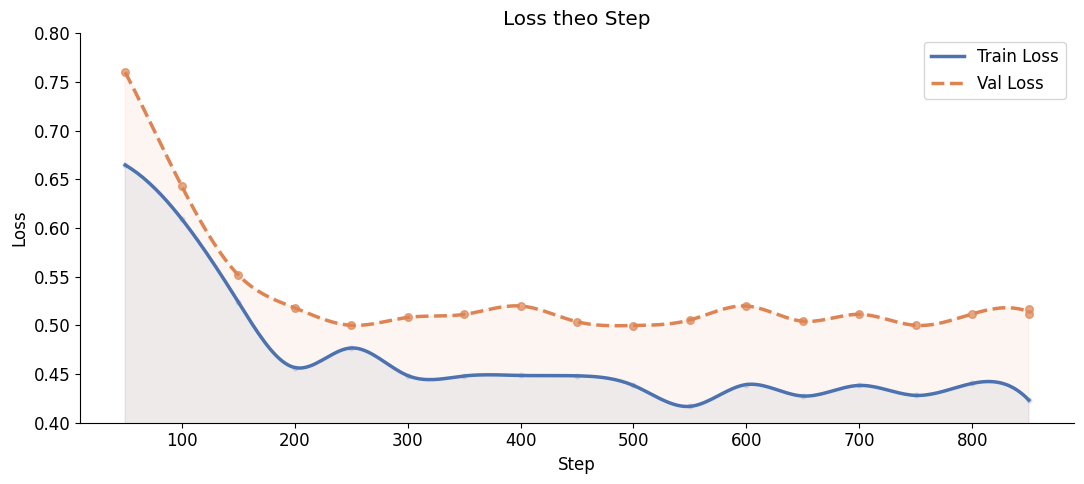

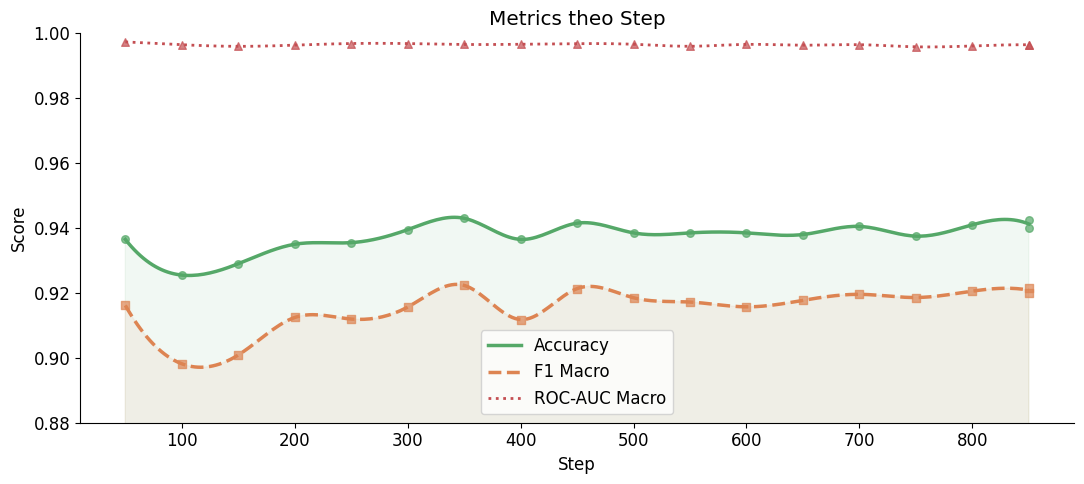

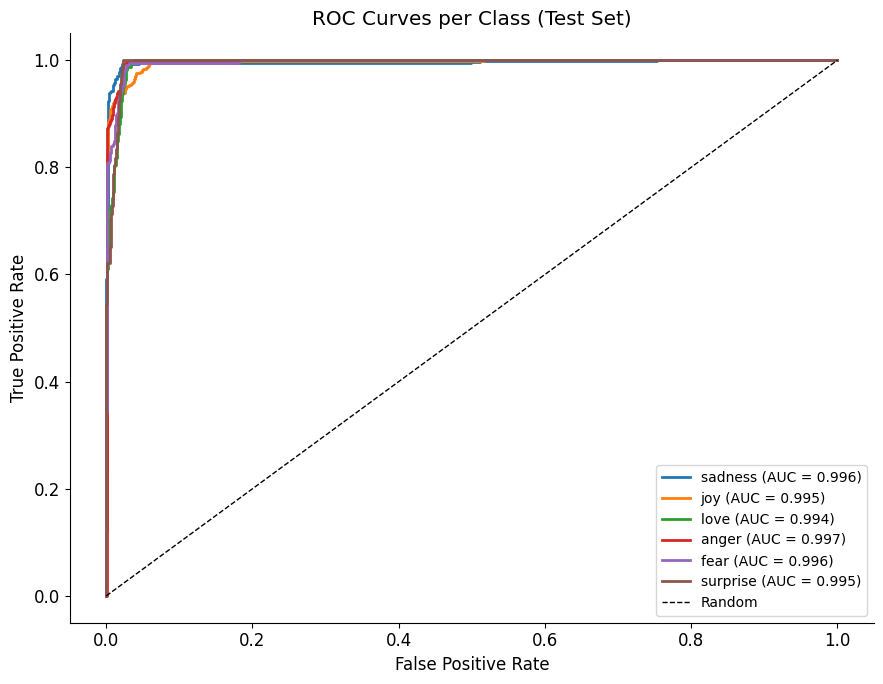

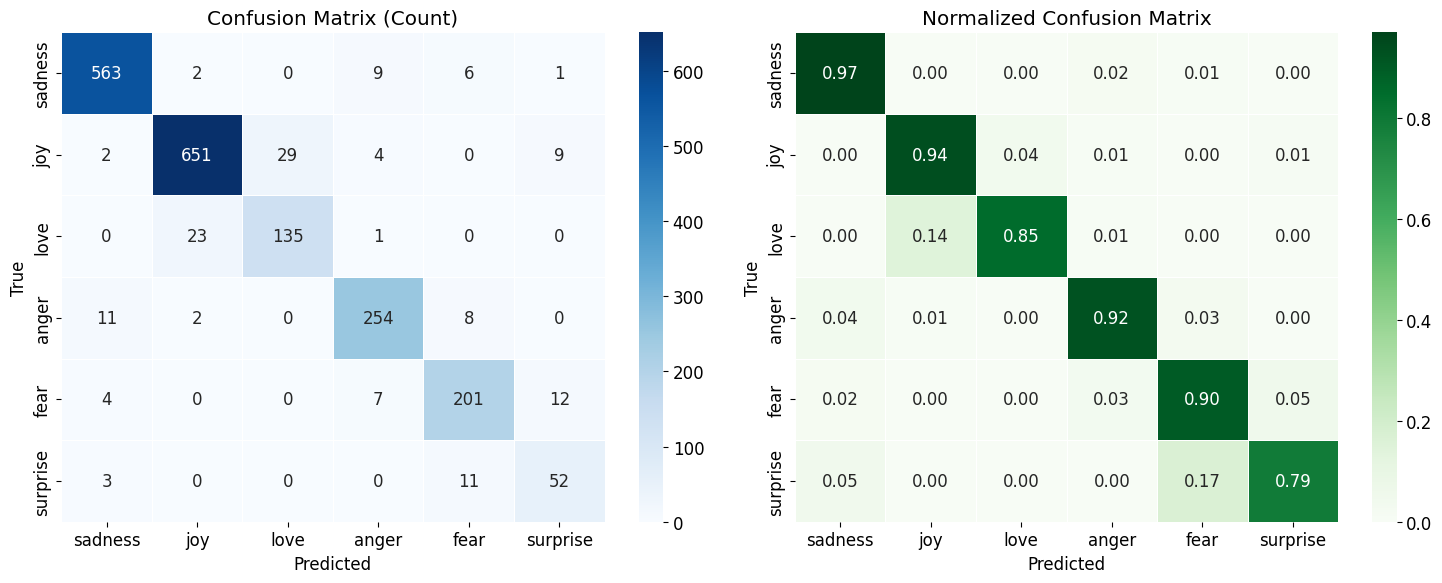

,Label,Precision,Recall,F1-score
0,sadness,0.9657,0.9690,0.9674
1,joy,0.9602,0.9367,0.9483
2,love,0.8232,0.8491,0.8359
3,anger,0.9236,0.9236,0.9236
4,fear,0.8894,0.8973,0.8933
5,surprise,0.7027,0.7879,0.7429


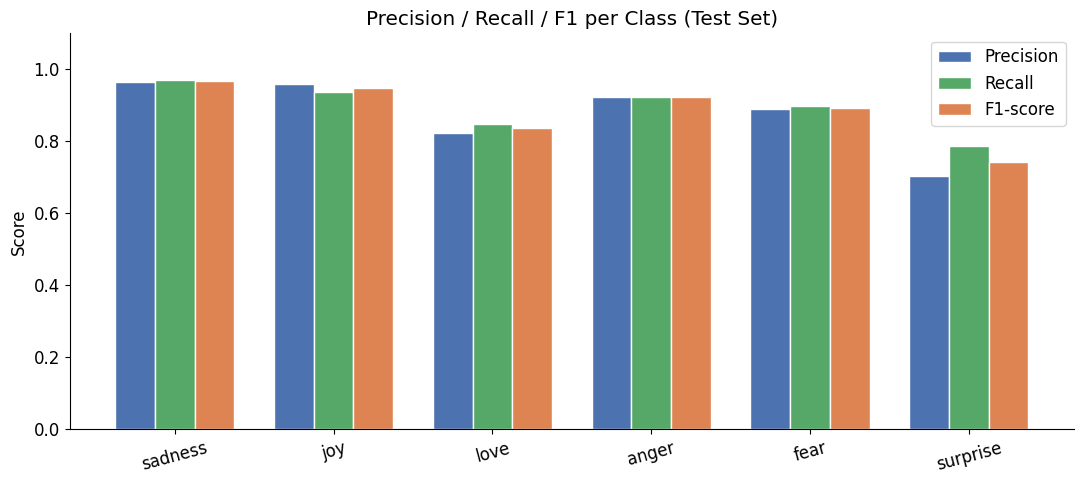


✓ Đã lưu tất cả biểu đồ vào /kaggle/working/


In [12]:
def smooth_curve(x, y, n_points=300):
    x, y = np.array(x, dtype=float), np.array(y, dtype=float)
    mask = ~np.isnan(y)
    x, y = x[mask], y[mask]
    if len(x) == 0:
        return x, y
    df_tmp = pd.DataFrame({"x": x, "y": y}).groupby("x", as_index=False).mean()
    x, y = df_tmp["x"].values, df_tmp["y"].values
    if len(x) < 4:
        return x, y
    x_new = np.linspace(x.min(), x.max(), n_points)
    spl = make_interp_spline(x, y, k=3)
    return x_new, spl(x_new)

plt.rcParams.update({"font.size": 12, "axes.spines.top": False, "axes.spines.right": False})
BLUE, ORANGE, GREEN, RED = "#4C72B0", "#DD8452", "#55A868", "#C44E52"

logs = pd.DataFrame(trainer.state.log_history)
train_steps  = logs[logs["loss"].notna()]["step"].values.astype(float)
train_losses = logs[logs["loss"].notna()]["loss"].values.astype(float)
eval_steps   = logs[logs["eval_loss"].notna()]["step"].values.astype(float)
eval_losses  = logs[logs["eval_loss"].notna()]["eval_loss"].values.astype(float)
eval_accs    = logs[logs["eval_accuracy"].notna()]["eval_accuracy"].values.astype(float) if "eval_accuracy" in logs else np.array([])
eval_f1s     = logs[logs["eval_f1_macro"].notna()]["eval_f1_macro"].values.astype(float) if "eval_f1_macro" in logs else np.array([])
eval_aucs    = logs[logs["eval_roc_auc_macro"].notna()]["eval_roc_auc_macro"].values.astype(float) if "eval_roc_auc_macro" in logs else np.array([])

# ── 1. Loss theo Step ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
sx, sy = smooth_curve(train_steps, train_losses)
ax.fill_between(sx, sy, alpha=0.08, color=BLUE)
ax.plot(sx, sy, color=BLUE, linewidth=2.5, label="Train Loss")
ax.scatter(train_steps, train_losses, alpha=0.15, s=12, color=BLUE)
if len(eval_steps) >= 2:
    vx, vy = smooth_curve(eval_steps, eval_losses)
    ax.fill_between(vx, vy, alpha=0.08, color=ORANGE)
    ax.plot(vx, vy, color=ORANGE, linewidth=2.5, linestyle="--", label="Val Loss")
    ax.scatter(eval_steps, eval_losses, s=30, color=ORANGE, zorder=5, alpha=0.7)
else:
    ax.scatter(eval_steps, eval_losses, s=40, color=ORANGE, label="Val Loss", zorder=5)
ax.set_xlabel("Step"); ax.set_ylabel("Loss")
ax.set_title("Loss theo Step")
ax.set_ylim(0.40, 0.80)
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
ax.legend(); fig.tight_layout()
fig.savefig("/kaggle/working/step_loss.png", dpi=150); plt.show()

# ── 2. Metrics theo Step ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
if len(eval_steps) > 0 and len(eval_accs) == len(eval_steps):
    if len(eval_steps) >= 4:
        ex, ey_acc = smooth_curve(eval_steps, eval_accs)
        ex, ey_f1  = smooth_curve(eval_steps, eval_f1s)
    else:
        ex, ey_acc, ey_f1 = eval_steps, eval_accs, eval_f1s
    ax.fill_between(ex, ey_acc, alpha=0.08, color=GREEN)
    ax.plot(ex, ey_acc, color=GREEN, linewidth=2.5, label="Accuracy")
    ax.scatter(eval_steps, eval_accs, s=30, color=GREEN, alpha=0.7, zorder=5)
    ax.fill_between(ex, ey_f1, alpha=0.08, color=ORANGE)
    ax.plot(ex, ey_f1, color=ORANGE, linewidth=2.5, linestyle="--", label="F1 Macro")
    ax.scatter(eval_steps, eval_f1s, s=30, color=ORANGE, alpha=0.7, zorder=5, marker="s")
    if len(eval_aucs) == len(eval_steps):
        if len(eval_steps) >= 4:
            _, ey_auc = smooth_curve(eval_steps, eval_aucs)
        else:
            ey_auc = eval_aucs
        ax.plot(ex if len(eval_steps) >= 4 else eval_steps, ey_auc,
                color=RED, linewidth=2, linestyle=":", label="ROC-AUC Macro")
        ax.scatter(eval_steps, eval_aucs, s=30, color=RED, alpha=0.7, zorder=5, marker="^")
ax.set_ylim(0.88, 1.0)
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.02))
ax.set_xlabel("Step"); ax.set_ylabel("Score")
ax.set_title("Metrics theo Step")
ax.legend(); fig.tight_layout()
fig.savefig("/kaggle/working/step_metrics.png", dpi=150); plt.show()

# ── 4. ROC Curves đa lớp ───────────────────────────────────────
lb_test = label_binarize(labels_test, classes=list(range(NUM_LABELS)))
fig, ax = plt.subplots(figsize=(9, 7))
cmap_tab = plt.get_cmap("tab10")
for c, name in enumerate(LABEL_NAMES):
    try:
        fpr, tpr, _ = roc_curve(lb_test[:, c], probs_test[:, c])
        ax.plot(fpr, tpr, color=cmap_tab(c), linewidth=2,
                label=f"{name} (AUC = {roc_auc_per_class[name]:.3f})")
    except Exception:
        pass
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves per Class (Test Set)")
ax.legend(loc="lower right", fontsize=10)
fig.tight_layout()
fig.savefig("/kaggle/working/roc_curves.png", dpi=150); plt.show()

# ── 5. Confusion Matrix ─────────────────────────────────────────
cm      = confusion_matrix(labels_test, preds_test)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            ax=axes[0], linewidths=0.4)
axes[0].set_title("Confusion Matrix (Count)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            ax=axes[1], linewidths=0.4)
axes[1].set_title("Normalized Confusion Matrix")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrices.png", dpi=150)
plt.show()

# ── 6. Per-class Precision / Recall / F1 bar chart ─────────────
report_dict = classification_report(
    labels_test, preds_test, target_names=LABEL_NAMES,
    output_dict=True, zero_division=0
)
per_class_df = pd.DataFrame({
    "Label":     LABEL_NAMES,
    "Precision": [report_dict[n]["precision"] for n in LABEL_NAMES],
    "Recall":    [report_dict[n]["recall"]    for n in LABEL_NAMES],
    "F1-score":  [report_dict[n]["f1-score"]  for n in LABEL_NAMES],
}).round(4)
display(per_class_df)

x = np.arange(len(LABEL_NAMES))
width = 0.25
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width, per_class_df["Precision"], width, label="Precision", color=BLUE,   edgecolor="white")
ax.bar(x,          per_class_df["Recall"],    width, label="Recall",    color=GREEN,  edgecolor="white")
ax.bar(x + width,  per_class_df["F1-score"],  width, label="F1-score",  color=ORANGE, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(LABEL_NAMES, rotation=15)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 per Class (Test Set)")
ax.legend()
fig.tight_layout()
fig.savefig("/kaggle/working/per_class_metrics.png", dpi=150)
plt.show()

print("\n✓ Đã lưu tất cả biểu đồ vào /kaggle/working/")


In [13]:
examples = [
    "I just got promoted at work and I'm so happy!",
    "I feel really sad and lonely today.",
    "I love spending time with my family on weekends.",
    "I'm furious because someone took credit for my idea.",
    "Wow, I didn't expect this surprise party at all!"
]

model.eval()
for i, text in enumerate(examples, 1):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH).to(device)
    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=-1)[0].cpu().numpy()
    pred_id = int(np.argmax(probs))
    pred_label = LABEL_NAMES[pred_id]
    conf = probs[pred_id]

    print(f"\nVí dụ {i}")
    print("-" * 80)
    print(f"Text       : {text}")
    print(f"Pred label : {pred_label}  (confidence={conf:.4f})")
    top3 = np.argsort(probs)[::-1][:3]
    print("Top-3:")
    for j in top3:
        print(f"  - {LABEL_NAMES[j]}: {probs[j]:.4f}")


Ví dụ 1
--------------------------------------------------------------------------------
Text       : I just got promoted at work and I'm so happy!
Pred label : joy  (confidence=0.9224)
Top-3:
  - joy: 0.9224
  - surprise: 0.0250
  - sadness: 0.0144

Ví dụ 2
--------------------------------------------------------------------------------
Text       : I feel really sad and lonely today.
Pred label : sadness  (confidence=0.8998)
Top-3:
  - sadness: 0.8998
  - surprise: 0.0450
  - love: 0.0260

Ví dụ 3
--------------------------------------------------------------------------------
Text       : I love spending time with my family on weekends.
Pred label : joy  (confidence=0.8390)
Top-3:
  - joy: 0.8390
  - love: 0.0708
  - anger: 0.0392

Ví dụ 4
--------------------------------------------------------------------------------
Text       : I'm furious because someone took credit for my idea.
Pred label : anger  (confidence=0.9604)
Top-3:
  - anger: 0.9604
  - surprise: 0.0195
  - fear: 0.0

In [14]:
trainer.save_model(os.path.join(OUTPUT_DIR, 'best_model'))
tokenizer.save_pretrained(os.path.join(OUTPUT_DIR, 'best_model'))
print('Saved to', os.path.join(OUTPUT_DIR, 'best_model'))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to /kaggle/working/emotion_finetune/best_model
